In [1]:
from langgraph.graph import StateGraph , START , END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict
import os

In [2]:
load_dotenv()

model = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.3-70b-versatile"
)

In [3]:
class Blogstate(TypedDict):

    title : str
    outline : str
    content : str

In [24]:
# First LLM 

def gen_outline (state : Blogstate) -> Blogstate:

    title = state['title']

    prompt = f'Generate a outline for the blog  {title}'

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

# Second LLM Call

def gen_blog(state : Blogstate) -> Blogstate:

    title = state['title']
    outline = state['outline']

    prompt = f'Create a blog with title {title} and with the outline {outline}'

    ontent = model.invoke(prompt).content

    state['content'] = ontent
    
    return state

In [25]:
graph = StateGraph(Blogstate)

graph.add_node('gen_outline' , gen_outline)
graph.add_node('gen_blog' , gen_blog)

graph.add_edge(START , 'gen_outline')
graph.add_edge('gen_outline' , 'gen_blog')
graph.add_edge('gen_blog' , END)

wf = graph.compile()

{'title': 'Cristiano_Ronaldo', 'outline': "Here is a suggested outline for a blog about Cristiano Ronaldo:\n\n**I. Introduction**\n\n* Brief overview of Cristiano Ronaldo's career and achievements\n* Importance of discussing Cristiano Ronaldo's life and career\n* Thesis statement: Cristiano Ronaldo is one of the most successful and influential soccer players of all time, with a career marked by incredible skill, dedication, and perseverance.\n\n**II. Early Life and Career**\n\n* Overview of Cristiano Ronaldo's childhood and early life in Madeira, Portugal\n* Discussion of his early soccer career, including his time at Sporting CP and his move to Manchester United\n* Key events and experiences that shaped his early career, such as his debut for Manchester United and his first major trophy wins\n\n**III. Rise to Fame**\n\n* Discussion of Cristiano Ronaldo's rapid rise to fame, including his move to Real Madrid and his success in the Spanish league\n* Overview of his major achievements, s

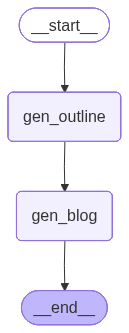

In [26]:
input = {'title' : 'Cristiano_Ronaldo'}

output = wf.invoke(input)

print(output)
wf

In [27]:
print(output['outline'])

Here is a suggested outline for a blog about Cristiano Ronaldo:

**I. Introduction**

* Brief overview of Cristiano Ronaldo's career and achievements
* Importance of discussing Cristiano Ronaldo's life and career
* Thesis statement: Cristiano Ronaldo is one of the most successful and influential soccer players of all time, with a career marked by incredible skill, dedication, and perseverance.

**II. Early Life and Career**

* Overview of Cristiano Ronaldo's childhood and early life in Madeira, Portugal
* Discussion of his early soccer career, including his time at Sporting CP and his move to Manchester United
* Key events and experiences that shaped his early career, such as his debut for Manchester United and his first major trophy wins

**III. Rise to Fame**

* Discussion of Cristiano Ronaldo's rapid rise to fame, including his move to Real Madrid and his success in the Spanish league
* Overview of his major achievements, such as winning the FIFA World Player of the Year award and t

In [28]:
print(output['content'])

**Cristiano_Ronaldo**

**I. Introduction**

Cristiano Ronaldo is one of the most recognizable names in the world of soccer. With a career spanning over two decades, he has achieved unparalleled success and has become a household name. From his humble beginnings in Madeira, Portugal to his current status as a global soccer icon, Cristiano Ronaldo's journey is a testament to his hard work, dedication, and perseverance. In this blog, we will delve into the life and career of Cristiano Ronaldo, exploring his early days, his rise to fame, and his numerous achievements. Cristiano Ronaldo is one of the most successful and influential soccer players of all time, with a career marked by incredible skill, dedication, and perseverance.

**II. Early Life and Career**

Cristiano Ronaldo was born on February 5, 1985, in Funchal, Madeira, Portugal. Growing up in a humble family, Ronaldo's love for soccer was evident from a young age. He began playing soccer at the age of eight and quickly rose throug

**Cristiano_Ronaldo**
================

**I. Introduction**

Cristiano Ronaldo is one of the most recognizable names in the world of soccer. With a career spanning over two decades, he has achieved unparalleled success and has become a household name. From his humble beginnings in Madeira, Portugal to his current status as a global soccer icon, Cristiano Ronaldo's journey is a testament to his hard work, dedication, and perseverance. In this blog, we will delve into the life and career of Cristiano Ronaldo, exploring his early days, his rise to fame, and his numerous achievements. Cristiano Ronaldo is one of the most successful and influential soccer players of all time, with a career marked by incredible skill, dedication, and perseverance.

**II. Early Life and Career**

Cristiano Ronaldo was born on February 5, 1985, in Funchal, Madeira, Portugal. Growing up in a humble family, Ronaldo's love for soccer was evident from a young age. He began playing soccer at the age of eight and quickly rose through the ranks, joining the youth team of local club CF Andorinha. At the age of 12, Ronaldo joined the youth academy of Sporting CP, one of the biggest clubs in Portugal. His impressive skills and dedication earned him a spot in the club's first team at just 17 years old. In 2003, Ronaldo made his professional debut for Sporting CP, scoring five goals in 31 appearances. His impressive performance caught the attention of Manchester United, who signed him in 2003. Ronaldo's time at Manchester United was marked by numerous successes, including three Premier League titles and a Champions League trophy.

**III. Rise to Fame**

Ronaldo's move to Real Madrid in 2009 marked the beginning of his rise to global fame. During his nine-year stint at the club, Ronaldo won an unprecedented four Champions League titles, two La Liga titles, and numerous individual awards, including the FIFA World Player of the Year award and the Ballon d'Or. His impressive playing style, which combines speed, skill, and power, has made him a fan favorite around the world. Ronaldo's success on the field has been matched by his charisma and marketability off the field, making him one of the most recognizable and marketable athletes in the world. His ability to score goals from anywhere on the field, his exceptional dribbling skills, and his leadership qualities have set him apart from other soccer players.

**IV. Career Highlights and Achievements**

Cristiano Ronaldo's career has been marked by numerous highlights and achievements. Some of his most notable achievements include:

* Winning the Champions League with Manchester United and Real Madrid
* Scoring record-breaking goals, including the fastest hat-trick in Champions League history
* Earning individual awards, such as the FIFA World Player of the Year award and the Ballon d'Or
* Leading Portugal to victory in the European Championship

Ronaldo's impact on the sport extends beyond his on-field achievements. He has inspired a generation of soccer players and has become a role model for millions of young athletes around the world. His dedication, work ethic, and passion for the sport have made him a beloved figure among soccer fans.
...

**VII. Conclusion**

Cristiano Ronaldo is a true soccer legend, with a career marked by incredible skill, dedication, and perseverance. From his humble beginnings in Madeira to his current status as a global icon, Ronaldo's journey is a testament to the power of hard work and determination. His numerous achievements, including his Champions League titles, his Ballon d'Or awards, and his European Championship victory, have cemented his place as one of the greatest soccer players of all time. Off the field, Ronaldo's philanthropic efforts and commitment to giving back to his community have made him a beloved figure among fans and non-fans alike. As he continues to play and inspire, Cristiano Ronaldo remains a compelling and inspiring figure, both on and off the field.
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...